In [4]:
# model
import torch
import torch.nn as nn
import torch.nn.functional as F
from torchsummary import summary
from torch import optim 
from torch.optim.lr_scheduler import StepLR

# dataset and transformation
from torchvision import datasets
import torchvision.transforms as transforms
from torch.utils.data import DataLoader
import os

# display images
from torchvision import utils
import matplotlib.pyplot as plt

# utils
import numpy as np
import time
import copy

In [5]:
# GPU 사용 가능 여부 확인
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

# GPU 이름 출력
if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))

# Load Dataset : STL10
# specify the data path
path2data = './rdata'

# if not exists the path, make the directory
if not os.path.exists(path2data):
    os.mkdir(path2data)

# load dataset
train_ds = datasets.STL10(path2data, split='train', download=True, transform=transforms.ToTensor())
val_ds = datasets.STL10(path2data, split='test',download=True, transform=transforms.ToTensor())

print(len(train_ds))
print(len(val_ds))

Using device: cuda
GPU: NVIDIA TITAN Xp


100%|██████████| 2.64G/2.64G [05:49<00:00, 7.55MB/s] 


Extracting ./rdata/stl10_binary.tar.gz to ./rdata
Files already downloaded and verified
5000
8000


In [9]:
# caculate mean & std
# dataset : caculate mean & std
# to normalize the dataset, calculate the mean and std
train_meanRGB = [np.mean(x.numpy(), axis=(1,2)) for x, _ in train_ds]
train_stdRGB = [np.std(x.numpy(), axis=(1,2)) for x, _ in train_ds]

train_meanR = np.mean([m[0] for m in train_meanRGB])
train_meanG = np.mean([m[1] for m in train_meanRGB])
train_meanB = np.mean([m[2] for m in train_meanRGB])
train_stdR = np.mean([s[0] for s in train_stdRGB])
train_stdG = np.mean([s[1] for s in train_stdRGB])
train_stdB = np.mean([s[2] for s in train_stdRGB])

val_meanRGB = [np.mean(x.numpy(), axis=(1,2)) for x, _ in val_ds]
val_stdRGB = [np.std(x.numpy(), axis=(1,2)) for x, _ in val_ds]

val_meanR = np.mean([m[0] for m in val_meanRGB])
val_meanG = np.mean([m[1] for m in val_meanRGB])
val_meanB = np.mean([m[2] for m in val_meanRGB])

val_stdR = np.mean([s[0] for s in val_stdRGB])
val_stdG = np.mean([s[1] for s in val_stdRGB])
val_stdB = np.mean([s[2] for s in val_stdRGB])

print(train_meanR, train_meanG, train_meanB)
print(val_meanR, val_meanG, val_meanB)

0.4467106 0.43980986 0.40664646
0.44723064 0.4396425 0.40495726


In [10]:
# define the image transformation 
train_transformation = transforms.Compose([
    transforms.ToTensor(),
    transforms.Resize(224),
    transforms.Normalize([train_meanR, train_meanG, train_meanB], [train_stdR, train_stdG, train_stdB]),
    transforms.RandomHorizontalFlip()
])

val_transformation = transforms.Compose([
    transforms.ToTensor(),
    transforms.Resize(224),
    transforms.Normalize([train_meanR, train_meanG, train_meanB], [train_stdR, train_stdG, train_stdB]),
])

# apply transformation
train_ds.transform = train_transformation
val_ds.transform = val_transformation

# create DataLoader
train_dl = DataLoader(train_ds, batch_size=32, shuffle=True)
val_dl = DataLoader(val_ds, batch_size=32, shuffle=True)

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.9929461..2.6500857].


image indices:  [ 235 3980  905 2763 2895  144 4225 2797]


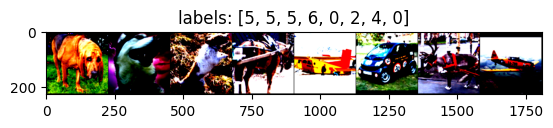

In [14]:
# image grid display
def show(img, y=None, color=True): # y:label
    npimg = img.numpy() # tensor -> numpy
    npimg_tr = np.transpose(npimg, (1,2,0)) # 차원 순서 변경
    plt.imshow(npimg_tr) # numpy 배열을 화면에 그림

    if y is not None: # 라벨이 있을 때만 실행
        plt.title('labels: '+ str(y)) # 이미지 위에 라벨 표시

# 랜덤 고정
np.random.seed(1) # numpy 랜덤 고정
torch.manual_seed(1) # pytorch 랜덤 고정

# train_dataset에서 8개 데이터 랜덤하게 선정
grid_size=8
rnd_inds = np.random.randint(0, len(train_ds), grid_size)
print('image indices: ', rnd_inds)

# 샘플 이미지와 라벨 추출
x_grid = [train_ds[i][0] for i in rnd_inds] # 데이터셋 : 이미지 데이터
y_grid = [train_ds[i][1] for i in rnd_inds] # 데이터셋 : 라벨

# 이미지들을 그리드 형태로 결합
x_grid = utils.make_grid(x_grid, nrow = grid_size, padding=2)

# 이미지 디스플레이 - 함수 호출
show(x_grid, y_grid)
